Loadinging in the dataset

In [ ]:
import glob, os
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if 'parquet' in root.lower():
        print(root)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

local_files_directory = '/content/drive/MyDrive/mit805/parquet_files_prepared'

parquet_files_paths = glob.glob(os.path.join(local_files_directory, 'yellow_tripdata_*.parquet'))
#calculating the size of the preprocessing dataset
total_bytes = sum(os.path.getsize(f) for f in parquet_files_paths)
total_gb = total_bytes / (1024**3)

print(f"Number of files: {len(parquet_files_paths)}")
print(f"Processing dataset size: {total_gb:.2f} GB")

Number of files: 143
Processing dataset size: 4.95 GB


In [ ]:
#checking the dataset
sample_file = parquet_files_paths[0]
df = pd.read_parquet(sample_file, columns=['tpep_pickup_datetime'])
hours = df['tpep_pickup_datetime'].dt.hour

In [ ]:
print(hours.value_counts().sort_index())

tpep_pickup_datetime
0     516629
1     384162
2     295417
3     218209
4     160762
13         9
18         2
19         8
20    802797
21    769694
22    749503
23    653108
Name: count, dtype: int64


EDA

# ANALYSIS 1:Trip volume over time

In [ ]:
#reading pickup time from each file to count trips per month
monthly_counts = [
    {'file_name': os.path.basename(f), 'trip_count': len(pd.read_parquet(f, columns=['tpep_pickup_datetime']))}
    for f in parquet_files_paths]

trips_by_month = pd.DataFrame(monthly_counts)

In [ ]:
#sorting the months in proper time order
trips_by_month['year_month'] = pd.to_datetime(trips_by_month['file_name'].str.extract(r'(\d{4}-\d{2})')[0])
trips_by_month = trips_by_month.sort_values('year_month').reset_index(drop=True)

In [ ]:
#basic stats on monthly trip counts
trips_by_month['trip_count'].describe()

,trip_count
count,1.430000e+02
mean,2.081185e+06
std,1.431983e+06
min,3.285800e+04
25%,9.093715e+05
50%,1.760431e+06
75%,3.206654e+06
max,5.256647e+06


In [ ]:
#the highest and lowest months
trips_by_month.loc[trips_by_month['trip_count'].idxmax()], trips_by_month.loc[trips_by_month['trip_count'].idxmin()]

(file_name     yellow_tripdata_2014-03.parquet
 trip_count                            5256647
 year_month                2014-03-01 00:00:00
 Name: 2, dtype: object,
 file_name     yellow_tripdata_2020-04.parquet
 trip_count                              32858
 year_month                2020-04-01 00:00:00
 Name: 75, dtype: object)

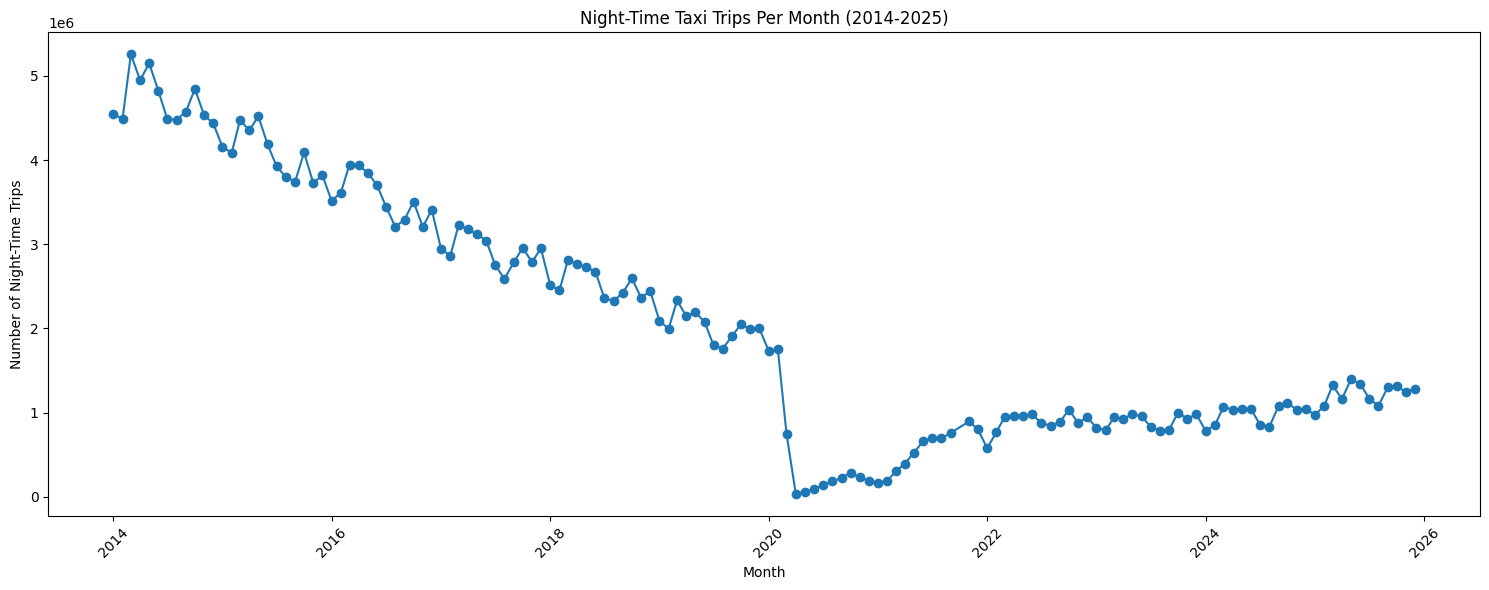

In [ ]:
import matplotlib.pyplot as plt

#trip volume trend over time
plt.figure(figsize=(15, 6))
plt.plot(trips_by_month['year_month'], trips_by_month['trip_count'], marker='o')
plt.title('Night-Time Taxi Trips Per Month (2014-2025)')
plt.xlabel('Month')
plt.ylabel('Number of Night-Time Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ANAYSIS 2: fair price overtime





In [ ]:
#reading fare amount from each file
monthly_fares = [
    {'file_name': os.path.basename(f), 'avg_fare': pd.read_parquet(f, columns=['fare_amount'])['fare_amount'].mean()}
    for f in parquet_files_paths
]

fares_by_month = pd.DataFrame(monthly_fares)

In [ ]:
#matching year-month order from before
fares_by_month['year_month'] = pd.to_datetime(fares_by_month['file_name'].str.extract(r'(\d{4}-\d{2})')[0])
fares_by_month = fares_by_month.sort_values('year_month').reset_index(drop=True)

In [ ]:

fares_by_month['avg_fare'].describe()

,avg_fare
count,143.000000
mean,14.880105
std,2.703029
min,12.216654
25%,13.064704
50%,13.412396
75%,17.172344
max,25.905141


In [ ]:

fares_by_month.loc[fares_by_month['avg_fare'].idxmax()], fares_by_month.loc[fares_by_month['avg_fare'].idxmin()]

(file_name     yellow_tripdata_2020-05.parquet
 avg_fare                            25.905141
 year_month                2020-05-01 00:00:00
 Name: 76, dtype: object,
 file_name     yellow_tripdata_2014-01.parquet
 avg_fare                            12.216654
 year_month                2014-01-01 00:00:00
 Name: 0, dtype: object)

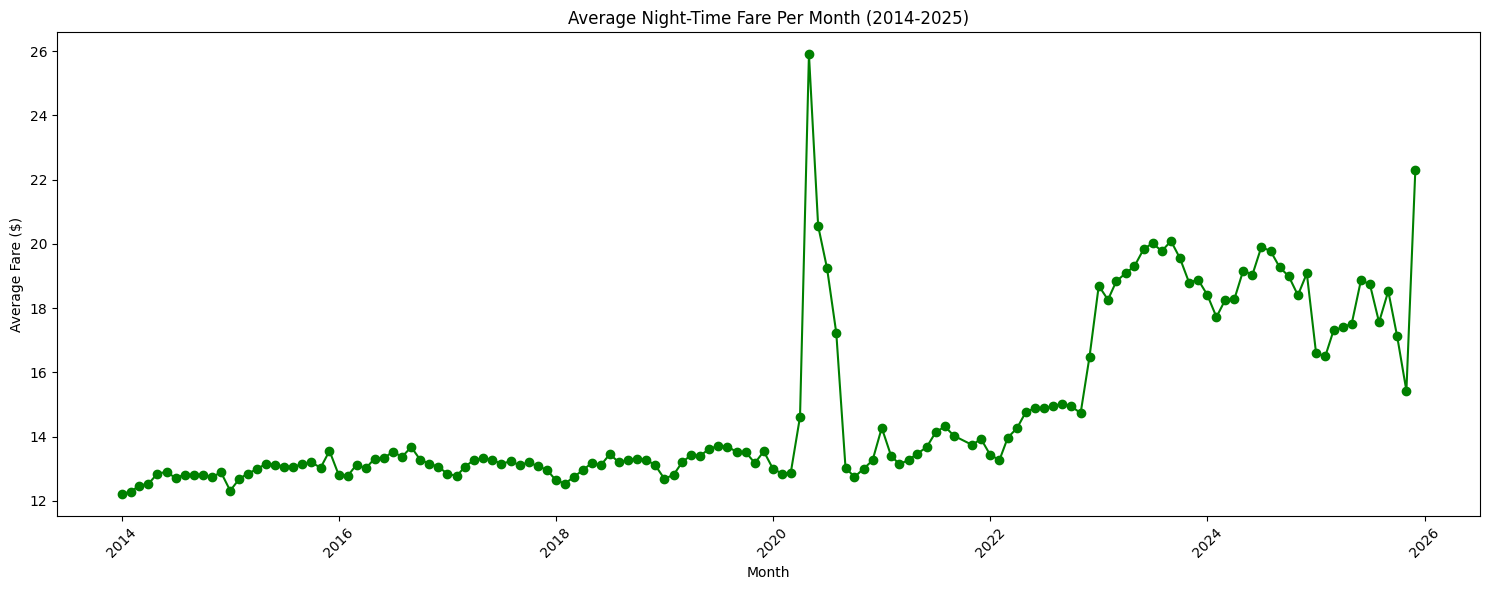

In [ ]:
#average fare trend over time
plt.figure(figsize=(15, 6))
plt.plot(fares_by_month['year_month'], fares_by_month['avg_fare'], marker='o', color='green')
plt.title('Average Night-Time Fare Per Month (2014-2025)')
plt.xlabel('Month')
plt.ylabel('Average Fare ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ANALYSIS 3: trip distance

In [ ]:
#reading trip distance from each file
monthly_distance = [
    {'file_name': os.path.basename(f), 'avg_distance': pd.read_parquet(f, columns=['trip_distance'])['trip_distance'].mean()}
    for f in parquet_files_paths
]

distance_by_month = pd.DataFrame(monthly_distance)

In [ ]:
#matching year-month order from before
distance_by_month['year_month'] = pd.to_datetime(distance_by_month['file_name'].str.extract(r'(\d{4}-\d{2})')[0])
distance_by_month = distance_by_month.sort_values('year_month').reset_index(drop=True)

In [ ]:
distance_by_month['avg_distance'].describe()

,avg_distance
count,143.000000
mean,6.213283
std,6.095051
min,3.048541
25%,3.289495
50%,4.482894
75%,6.254962
max,45.623635


In [ ]:
#longest and shortest average distance months
distance_by_month.loc[distance_by_month['avg_distance'].idxmax()], distance_by_month.loc[distance_by_month['avg_distance'].idxmin()]

(file_name       yellow_tripdata_2014-08.parquet
 avg_distance                          45.623635
 year_month                  2014-08-01 00:00:00
 Name: 7, dtype: object,
 file_name       yellow_tripdata_2014-02.parquet
 avg_distance                           3.048541
 year_month                  2014-02-01 00:00:00
 Name: 1, dtype: object)

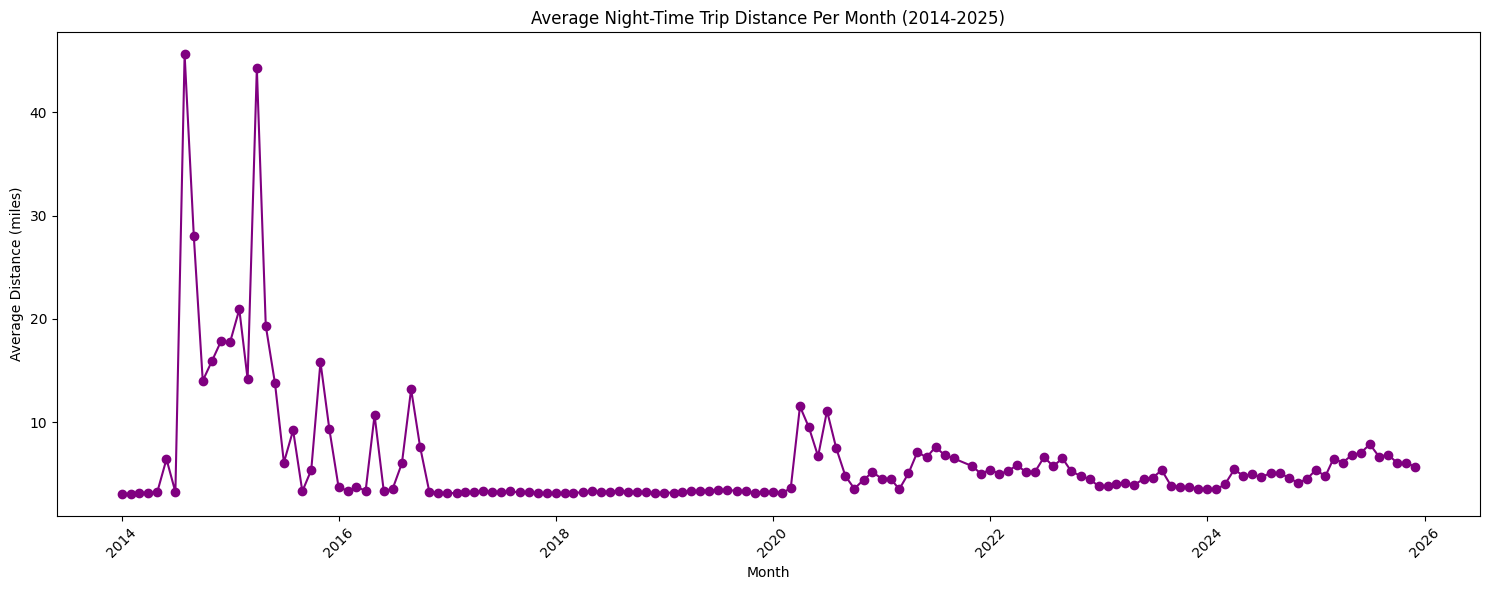

In [ ]:
#average trip distance trend over time
plt.figure(figsize=(15, 6))
plt.plot(distance_by_month['year_month'], distance_by_month['avg_distance'], marker='o', color='purple')
plt.title('Average Night-Time Trip Distance Per Month (2014-2025)')
plt.xlabel('Month')
plt.ylabel('Average Distance (miles)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analysis 4: Passenger count + distribution checks

In [ ]:
#sampling files for distribution checks
sample_files = parquet_files_paths[::10]

dist_df = pd.concat([
    pd.read_parquet(f, columns=['fare_amount', 'trip_distance', 'passenger_count'])
    for f in sample_files
], ignore_index=True)

dist_df[['fare_amount', 'trip_distance', 'passenger_count']].describe()

,fare_amount,trip_distance,passenger_count
count,3.283614e+07,3.283614e+07,32137131.0
mean,1.365493e+01,5.338068e+00,1.637809
std,9.066453e+01,3.772126e+03,1.240419
min,-8.000000e+02,-3.494000e+01,1.0
25%,7.000000e+00,1.140000e+00,1.0
50%,1.000000e+01,2.000000e+00,1.0
75%,1.600000e+01,3.810000e+00,2.0
max,5.052968e+05,1.200000e+07,6.0


In [ ]:
#checking for anomalies
print("Negative or zero fares:", (dist_df['fare_amount'] <= 0).sum())
print("Zero passenger trips:", (dist_df['passenger_count'] == 0).sum())
print("Trips over 100 miles:", (dist_df['trip_distance'] > 100).sum())
print("Fares over $200:", (dist_df['fare_amount'] > 200).sum())

Negative or zero fares: 218874
Zero passenger trips: 0
Trips over 100 miles: 328
Fares over $200: 4823


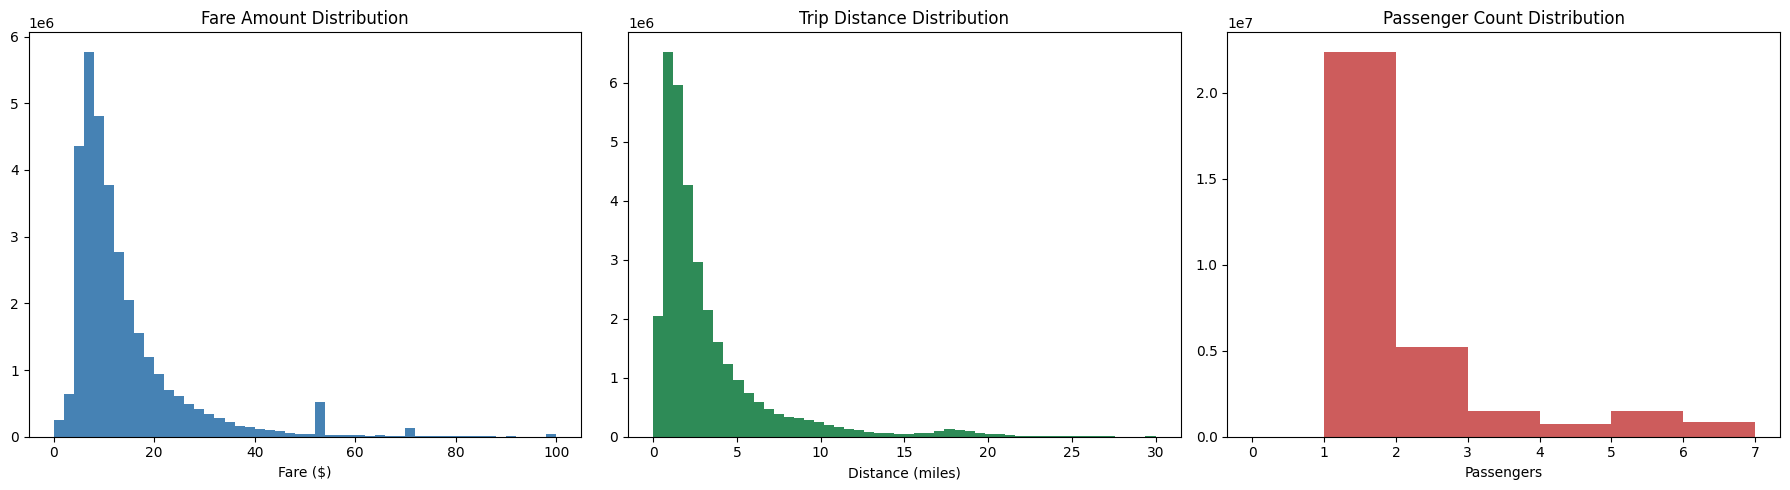

In [ ]:
#distribution of fare, distance, passenger count
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(dist_df['fare_amount'].clip(0, 100), bins=50, color='steelblue')
axes[0].set_title('Fare Amount Distribution')
axes[0].set_xlabel('Fare ($)')

axes[1].hist(dist_df['trip_distance'].clip(0, 30), bins=50, color='seagreen')
axes[1].set_title('Trip Distance Distribution')
axes[1].set_xlabel('Distance (miles)')

axes[2].hist(dist_df['passenger_count'].dropna(), bins=range(0, 8), color='indianred')
axes[2].set_title('Passenger Count Distribution')
axes[2].set_xlabel('Passengers')

plt.tight_layout()
plt.show()

# Analysis 5: Distance vs fare relationship

Correlation: 0.005


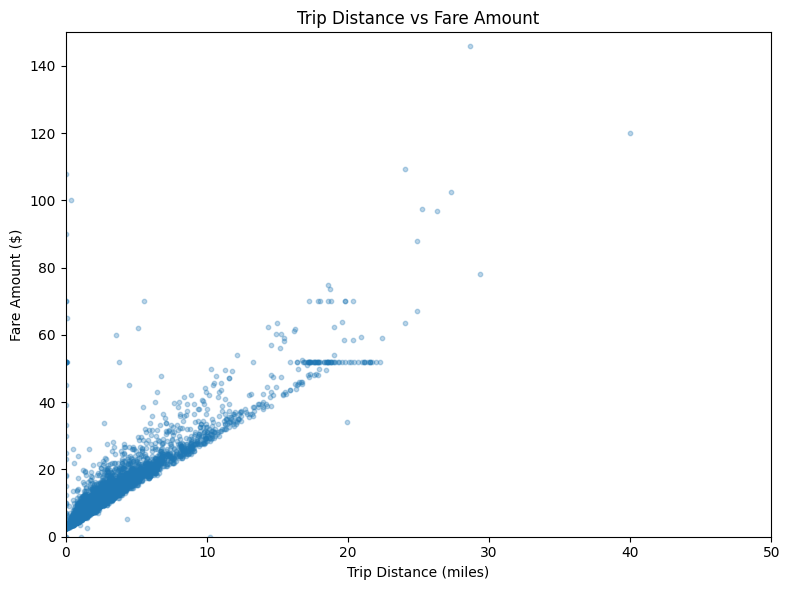

In [ ]:
#correlation between distance and fare
corr = dist_df['trip_distance'].corr(dist_df['fare_amount'])
print(f"Correlation: {corr:.3f}")

scatter_sample = dist_df.sample(5000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(scatter_sample['trip_distance'], scatter_sample['fare_amount'], alpha=0.3, s=10)
plt.xlim(0, 50)
plt.ylim(0, 150)
plt.title('Trip Distance vs Fare Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.tight_layout()
plt.show()

# Analysis 6: Hour-level breakdown

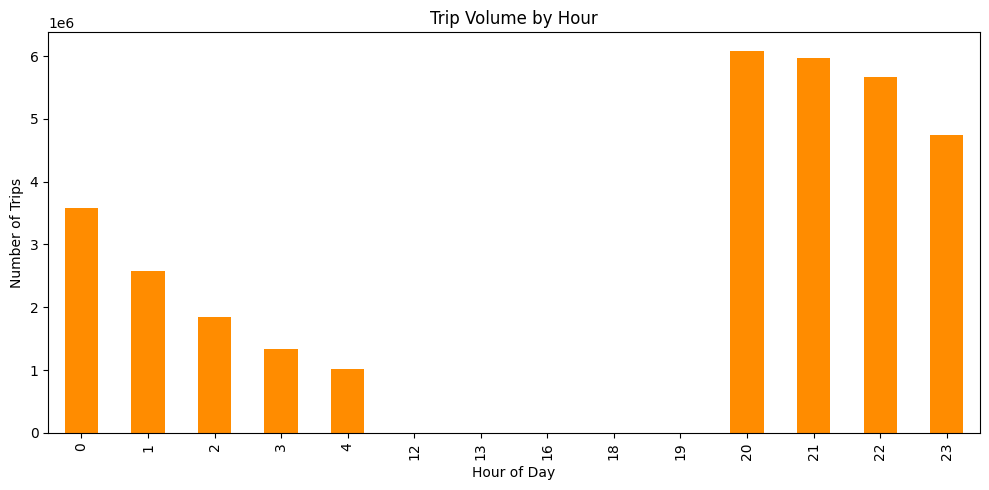

In [ ]:
#trip counts by hour within night window
hour_counts = pd.concat([
    pd.read_parquet(f, columns=['tpep_pickup_datetime'])['tpep_pickup_datetime'].dt.hour
    for f in sample_files
], ignore_index=True).value_counts().sort_index()

plt.figure(figsize=(10, 5))
hour_counts.plot(kind='bar', color='darkorange')
plt.title('Trip Volume by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.show()

# Anaylysis 7: Payment type / vendor breakdown

In [ ]:
cat_df = pd.concat([
    pd.read_parquet(f, columns=['payment_type', 'VendorID'])
    for f in sample_files
], ignore_index=True)

print(cat_df['payment_type'].unique())
print(cat_df['VendorID'].unique())

[1 2 4 3 5 0]
<IntegerArray>
[2, 1, 3, 4, 5, 6, 7]
Length: 7, dtype: Int64


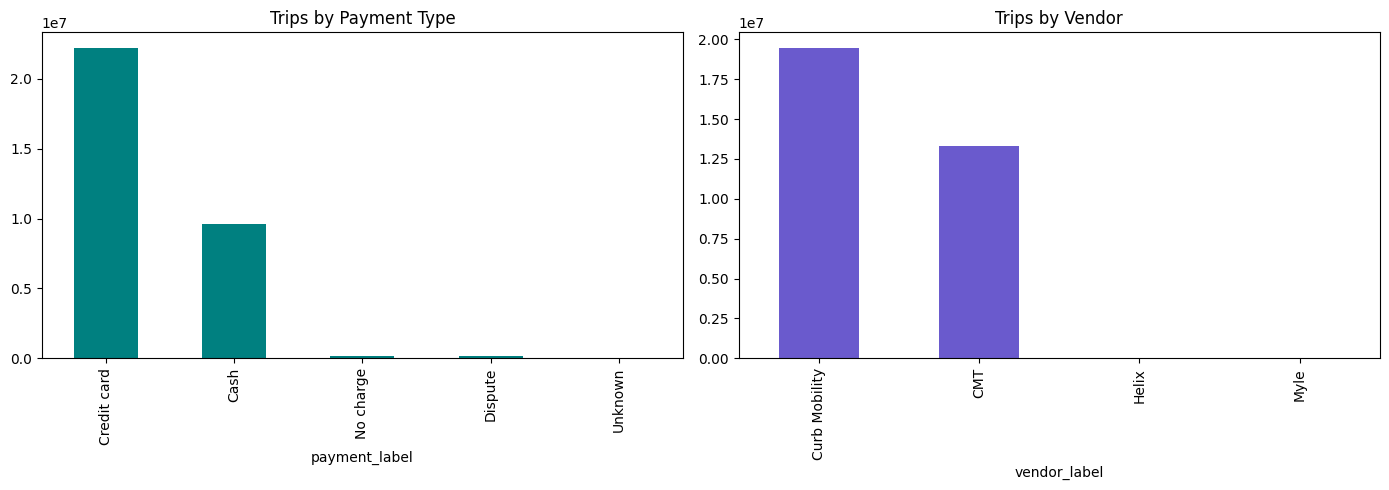

In [ ]:
#payment type and vendor counts
cat_df = pd.concat([
    pd.read_parquet(f, columns=['payment_type', 'VendorID'])
    for f in sample_files
], ignore_index=True)

#mapping codes to readable labels
payment_map = {1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}

vendor_map = {1: 'CMT', 2: 'Curb Mobility', 6: 'Myle', 7: 'Helix'}
cat_df['vendor_label'] = cat_df['VendorID'].map(vendor_map).fillna('Unknown/undocumented')


cat_df['payment_label'] = cat_df['payment_type'].map(payment_map)
cat_df['vendor_label'] = cat_df['VendorID'].map(vendor_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_df['payment_label'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Trips by Payment Type')

cat_df['vendor_label'].value_counts().plot(kind='bar', ax=axes[1], color='slateblue')
axes[1].set_title('Trips by Vendor')

plt.tight_layout()
plt.show()

In [ ]:
cat_df['VendorID'].value_counts(normalize=True) * 100

,proportion
VendorID,
2,59.284591
1,40.583701
4,0.063847
7,0.05652
6,0.007218
3,0.004032
5,0.000091
